# HW08-09: PyTorch MLP - регуляризация и оптимизация обучения

## 1. Импорты, seed и устройство

In [46]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import json
import pandas as pd

# Фиксируем seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


## 2. Данные и DataLoader

In [ ]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  
])


train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)
dataset_name = "EMNIST_balanced"
print(f"Используем датасет: {dataset_name}")

class_names = train_full.classes
print(f"classes: {class_names}")
print(f"train size: {len(train_full)}")
print(f"test size: {len(test_ds)}")

Используем датасет: EMNIST_balanced
classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [ ]:

BATCH_SIZE = 256 if device.type == "cuda" else 64


NUM_WORKERS = 0 if os.name == "nt" else 2


val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Sanity-check
x_batch, y_batch = next(iter(train_loader))
print(f"x_batch: {x_batch.shape}, {x_batch.dtype}")
print(f"y_batch: {y_batch.shape}, {y_batch.dtype}")

x_batch: torch.Size([64, 1, 28, 28]), torch.float32
y_batch: torch.Size([64]), torch.int64


## 3. Модель MLP и цикл обучения

In [ ]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,  
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


input_dim = x_batch.view(x_batch.size(0), -1).size(1)
num_classes = len(class_names)


model = MLP(input_dim=input_dim, num_classes=num_classes, dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print(f"logits: {out.shape}")

logits: torch.Size([64, 47])


In [ ]:

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [ ]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

# Функция для обучения модели
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [52]:
# Функция для построения графиков
def plot_and_save_history(history: dict, title: str = "", save_path: str = None) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

## 4. Эксперименты A: регуляризация и переобучение (E1-E4)

E1 (base): MLP без Dropout и BatchNorm
epoch 01/20 | train loss=1.1384, acc=0.6640 | val loss=0.7422, acc=0.7717
epoch 02/20 | train loss=0.6630, acc=0.7871 | val loss=0.6404, acc=0.7967
epoch 03/20 | train loss=0.5652, acc=0.8117 | val loss=0.5610, acc=0.8218
epoch 04/20 | train loss=0.5121, acc=0.8256 | val loss=0.5785, acc=0.8103
epoch 05/20 | train loss=0.4780, acc=0.8352 | val loss=0.5261, acc=0.8339
epoch 06/20 | train loss=0.4497, acc=0.8431 | val loss=0.5247, acc=0.8316
epoch 07/20 | train loss=0.4279, acc=0.8489 | val loss=0.5287, acc=0.8263
epoch 08/20 | train loss=0.4123, acc=0.8521 | val loss=0.5408, acc=0.8258
epoch 09/20 | train loss=0.3995, acc=0.8570 | val loss=0.4926, acc=0.8372
epoch 10/20 | train loss=0.3829, acc=0.8614 | val loss=0.5349, acc=0.8319
epoch 11/20 | train loss=0.3705, acc=0.8645 | val loss=0.5245, acc=0.8321
epoch 12/20 | train loss=0.3603, acc=0.8672 | val loss=0.5122, acc=0.8378
epoch 13/20 | train loss=0.3527, acc=0.8683 | val loss=0.5418, acc=0.8261

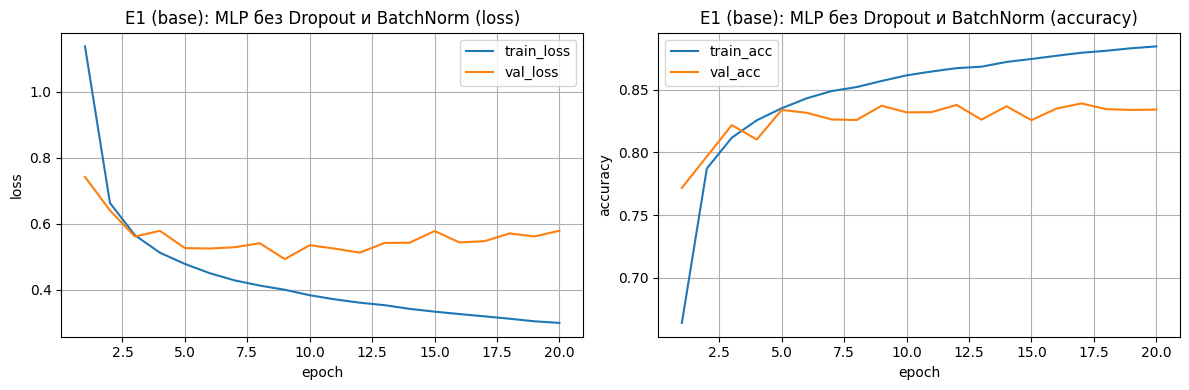

E1 test: loss=0.6225, acc=0.8260


In [ ]:
# E1
set_seed(42)
e1_model = MLP(input_dim=input_dim, num_classes=num_classes, hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_e1 = optim.Adam(e1_model.parameters(), lr=1e-3)

print("E1 (base): MLP без Dropout и BatchNorm")
history_e1 = fit(
    e1_model, train_loader, val_loader,
    optimizer_e1, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_and_save_history(history_e1, title="E1 (base): MLP без Dropout и BatchNorm", save_path="./artifacts/figures/history_e1.png")

test_loss, test_acc = evaluate(e1_model, test_loader, criterion, device)
print(f"E1 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

E2 (Dropout): MLP с Dropout(p=0.3)
epoch 01/20 | train loss=1.5226, acc=0.5545 | val loss=0.8575, acc=0.7380
epoch 02/20 | train loss=1.0389, acc=0.6793 | val loss=0.7161, acc=0.7772
epoch 03/20 | train loss=0.9352, acc=0.7038 | val loss=0.6698, acc=0.7832
epoch 04/20 | train loss=0.8875, acc=0.7201 | val loss=0.6355, acc=0.7941
epoch 05/20 | train loss=0.8584, acc=0.7269 | val loss=0.6117, acc=0.8069
epoch 06/20 | train loss=0.8334, acc=0.7330 | val loss=0.6091, acc=0.8034
epoch 07/20 | train loss=0.8159, acc=0.7388 | val loss=0.5767, acc=0.8149
epoch 08/20 | train loss=0.8065, acc=0.7426 | val loss=0.5860, acc=0.8141
epoch 09/20 | train loss=0.7877, acc=0.7466 | val loss=0.5640, acc=0.8156
epoch 10/20 | train loss=0.7801, acc=0.7488 | val loss=0.5757, acc=0.8134
epoch 11/20 | train loss=0.7722, acc=0.7500 | val loss=0.5445, acc=0.8211
epoch 12/20 | train loss=0.7597, acc=0.7525 | val loss=0.5479, acc=0.8183
epoch 13/20 | train loss=0.7579, acc=0.7543 | val loss=0.5425, acc=0.8229
epo

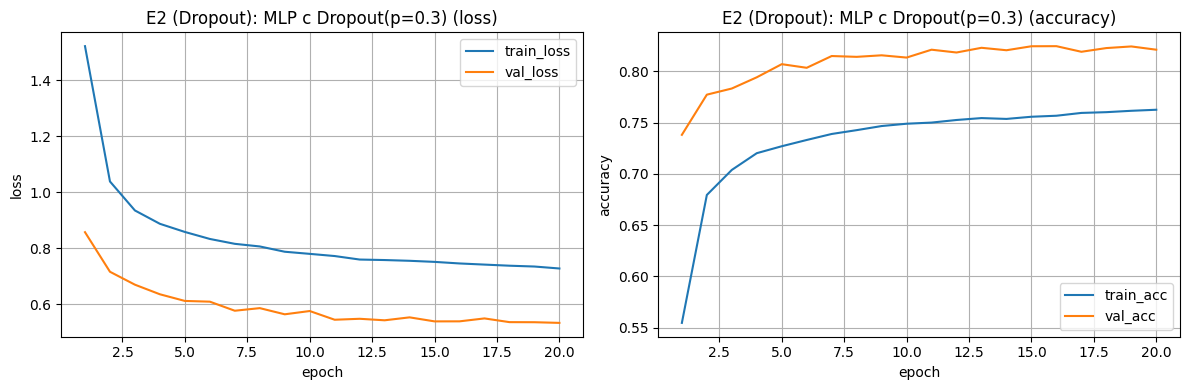

E2 test: loss=0.5489, acc=0.8137


In [ ]:
# E2
set_seed(42)
e2_model = MLP(input_dim=input_dim, num_classes=num_classes, hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

optimizer_e2 = optim.Adam(e2_model.parameters(), lr=1e-3)

print("E2 (Dropout): MLP с Dropout(p=0.3)")
history_e2 = fit(
    e2_model, train_loader, val_loader,
    optimizer_e2, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_and_save_history(history_e2, title="E2 (Dropout): MLP с Dropout(p=0.3)", save_path="./artifacts/figures/history_e2.png")

test_loss, test_acc = evaluate(e2_model, test_loader, criterion, device)
print(f"E2 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

E3 (BatchNorm): MLP с BatchNorm
epoch 01/20 | train loss=0.8866, acc=0.7435 | val loss=0.5710, acc=0.8150
epoch 02/20 | train loss=0.5277, acc=0.8230 | val loss=0.5194, acc=0.8264
epoch 03/20 | train loss=0.4605, acc=0.8420 | val loss=0.4663, acc=0.8425
epoch 04/20 | train loss=0.4172, acc=0.8528 | val loss=0.4687, acc=0.8468
epoch 05/20 | train loss=0.3858, acc=0.8613 | val loss=0.4564, acc=0.8441
epoch 06/20 | train loss=0.3665, acc=0.8680 | val loss=0.4538, acc=0.8475
epoch 07/20 | train loss=0.3463, acc=0.8732 | val loss=0.4520, acc=0.8496
epoch 08/20 | train loss=0.3296, acc=0.8770 | val loss=0.4507, acc=0.8524
epoch 09/20 | train loss=0.3154, acc=0.8814 | val loss=0.4474, acc=0.8517
epoch 10/20 | train loss=0.3001, acc=0.8872 | val loss=0.4408, acc=0.8535
epoch 11/20 | train loss=0.2906, acc=0.8896 | val loss=0.4508, acc=0.8539
epoch 12/20 | train loss=0.2798, acc=0.8913 | val loss=0.4557, acc=0.8550
epoch 13/20 | train loss=0.2686, acc=0.8968 | val loss=0.4779, acc=0.8496
epoch 

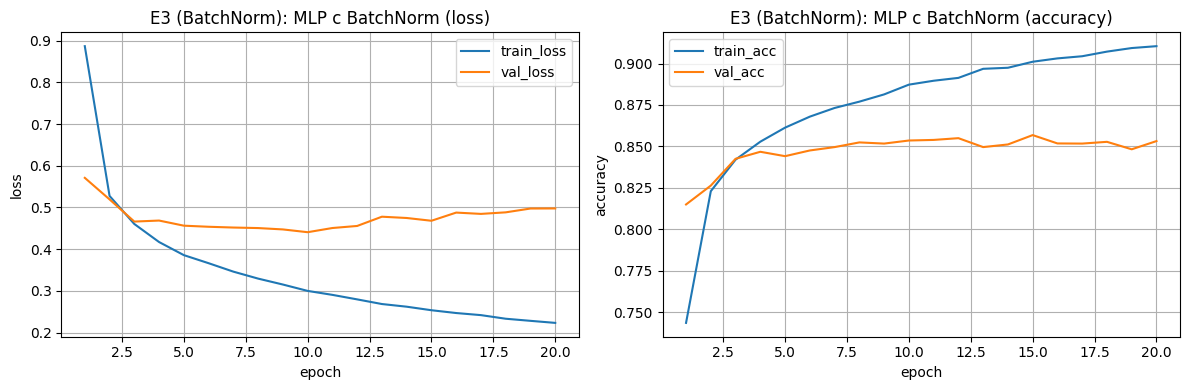

E3 test: loss=0.5152, acc=0.8500


In [ ]:
# E3
set_seed(42)
e3_model = MLP(input_dim=input_dim, num_classes=num_classes, hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

optimizer_e3 = optim.Adam(e3_model.parameters(), lr=1e-3)

print("E3 (BatchNorm): MLP с BatchNorm")
history_e3 = fit(
    e3_model, train_loader, val_loader,
    optimizer_e3, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_and_save_history(history_e3, title="E3 (BatchNorm): MLP с BatchNorm", save_path="./artifacts/figures/history_e3.png")

test_loss, test_acc = evaluate(e3_model, test_loader, criterion, device)
print(f"E3 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

E2 val_acc: 0.8211
E3 val_acc: 0.8532
Выбираем E3 (BatchNorm) как лучший для E4
E4 (EarlyStopping): лучшая модель с EarlyStopping
epoch 01/30 | train loss=0.8866, acc=0.7435 | val loss=0.5710, acc=0.8150
epoch 02/30 | train loss=0.5277, acc=0.8230 | val loss=0.5194, acc=0.8264
epoch 03/30 | train loss=0.4605, acc=0.8420 | val loss=0.4663, acc=0.8425
epoch 04/30 | train loss=0.4172, acc=0.8528 | val loss=0.4687, acc=0.8468
epoch 05/30 | train loss=0.3858, acc=0.8613 | val loss=0.4564, acc=0.8441
epoch 06/30 | train loss=0.3665, acc=0.8680 | val loss=0.4538, acc=0.8475
epoch 07/30 | train loss=0.3463, acc=0.8732 | val loss=0.4520, acc=0.8496
epoch 08/30 | train loss=0.3296, acc=0.8770 | val loss=0.4507, acc=0.8524
epoch 09/30 | train loss=0.3154, acc=0.8814 | val loss=0.4474, acc=0.8517
epoch 10/30 | train loss=0.3001, acc=0.8872 | val loss=0.4408, acc=0.8535
epoch 11/30 | train loss=0.2906, acc=0.8896 | val loss=0.4508, acc=0.8539
epoch 12/30 | train loss=0.2798, acc=0.8913 | val loss=0

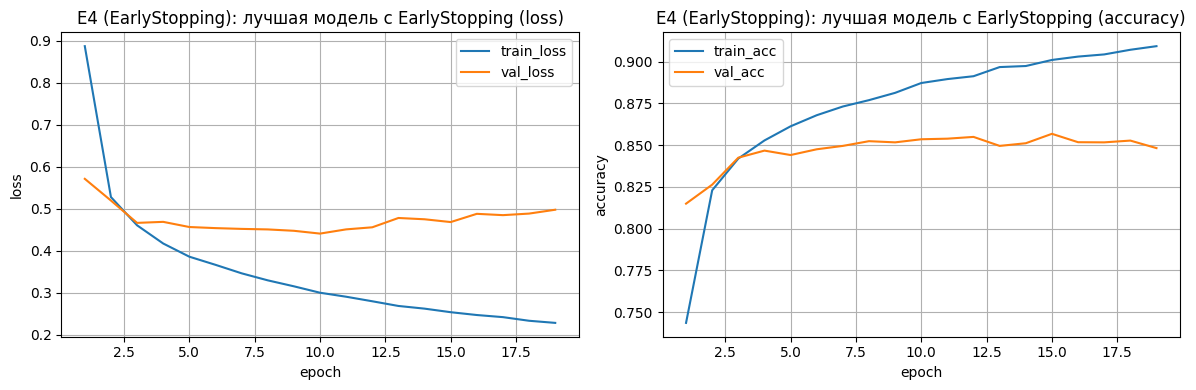

E4 test: loss=0.4896, acc=0.8534


In [ ]:
# E4 
e2_val_acc = history_e2["val_acc"][-1]
e3_val_acc = history_e3["val_acc"][-1]

print(f"E2 val_acc: {e2_val_acc:.4f}")
print(f"E3 val_acc: {e3_val_acc:.4f}")

if e2_val_acc > e3_val_acc:
    print("Выбираем E2 (Dropout) как лучший для E4")
    best_hidden_dims = (256, 128)
    best_dropout_p = 0.3
    best_use_batchnorm = False
else:
    print("Выбираем E3 (BatchNorm) как лучший для E4")
    best_hidden_dims = (256, 128)
    best_dropout_p = 0.0
    best_use_batchnorm = True

set_seed(42)
e4_model = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=best_hidden_dims,
    dropout_p=best_dropout_p,
    use_batchnorm=best_use_batchnorm
).to(device)

optimizer_e4 = optim.Adam(e4_model.parameters(), lr=1e-3)
es = EarlyStopping(patience=4, min_delta=0.0005)

print(f"E4 (EarlyStopping): лучшая модель с EarlyStopping")
history_e4 = fit(
    e4_model, train_loader, val_loader,
    optimizer_e4, criterion, device,
    epochs=30, 
    early_stopping=es,
    verbose=True
)

plot_and_save_history(history_e4, title="E4 (EarlyStopping): лучшая модель с EarlyStopping", save_path="./artifacts/figures/history_e4.png")

test_loss, test_acc = evaluate(e4_model, test_loader, criterion, device)
print(f"E4 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## 5. Эксперименты B: LR, оптимизаторы, weight decay (O1-O3)

O1 (LR слишком большой): Adam, lr = 1e-1
epoch 01/8 | train loss=1.1927, acc=0.6427 | val loss=0.8845, acc=0.7283
epoch 02/8 | train loss=0.8771, acc=0.7269 | val loss=0.7458, acc=0.7617
epoch 03/8 | train loss=0.8086, acc=0.7472 | val loss=0.7167, acc=0.7717
epoch 04/8 | train loss=0.7639, acc=0.7583 | val loss=0.7101, acc=0.7699
epoch 05/8 | train loss=0.7231, acc=0.7694 | val loss=0.7118, acc=0.7892
epoch 06/8 | train loss=0.7148, acc=0.7729 | val loss=0.6602, acc=0.7914
epoch 07/8 | train loss=0.6867, acc=0.7800 | val loss=0.6720, acc=0.7996
epoch 08/8 | train loss=0.6687, acc=0.7839 | val loss=0.6869, acc=0.7844


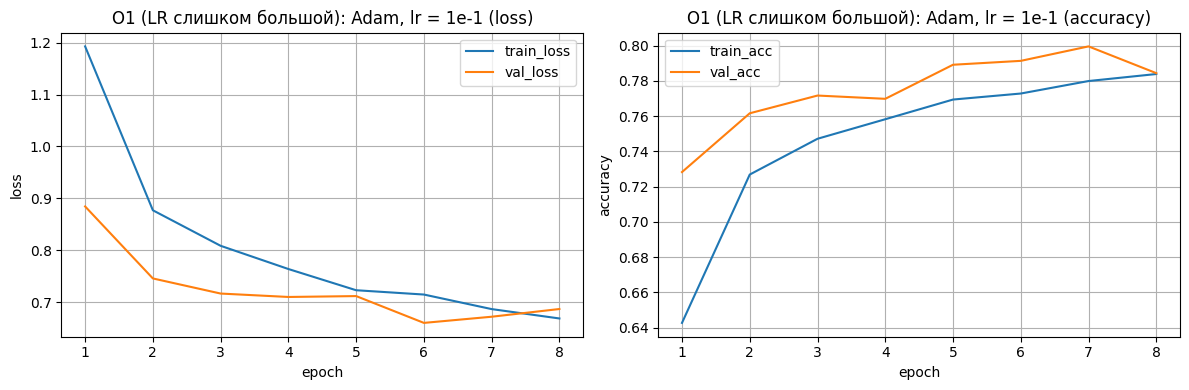

O1 test: loss=0.6995, acc=0.7869


In [ ]:
# O1 
set_seed(42)
o1_model = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=best_hidden_dims,
    dropout_p=best_dropout_p,
    use_batchnorm=best_use_batchnorm
).to(device)

optimizer_o1 = optim.Adam(o1_model.parameters(), lr=1e-1) 

print("O1 (LR слишком большой): Adam, lr = 1e-1")
history_o1 = fit(
    o1_model, train_loader, val_loader,
    optimizer_o1, criterion, device,
    epochs=8,  
    early_stopping=None,
    verbose=True
)

plot_and_save_history(history_o1, title="O1 (LR слишком большой): Adam, lr = 1e-1", save_path="./artifacts/figures/history_o1.png")


test_loss, test_acc = evaluate(o1_model, test_loader, criterion, device)
print(f"O1 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

O2 (LR слишком маленький): Adam, lr = 1e-5
epoch 01/8 | train loss=3.2802, acc=0.2490 | val loss=2.8342, acc=0.4371
epoch 02/8 | train loss=2.6035, acc=0.4980 | val loss=2.3592, acc=0.5579
epoch 03/8 | train loss=2.2144, acc=0.5809 | val loss=2.0260, acc=0.6186
epoch 04/8 | train loss=1.9200, acc=0.6275 | val loss=1.7733, acc=0.6532
epoch 05/8 | train loss=1.6871, acc=0.6589 | val loss=1.5650, acc=0.6758
epoch 06/8 | train loss=1.5042, acc=0.6800 | val loss=1.3982, acc=0.6977
epoch 07/8 | train loss=1.3573, acc=0.7001 | val loss=1.2779, acc=0.7118
epoch 08/8 | train loss=1.2377, acc=0.7152 | val loss=1.1646, acc=0.7252


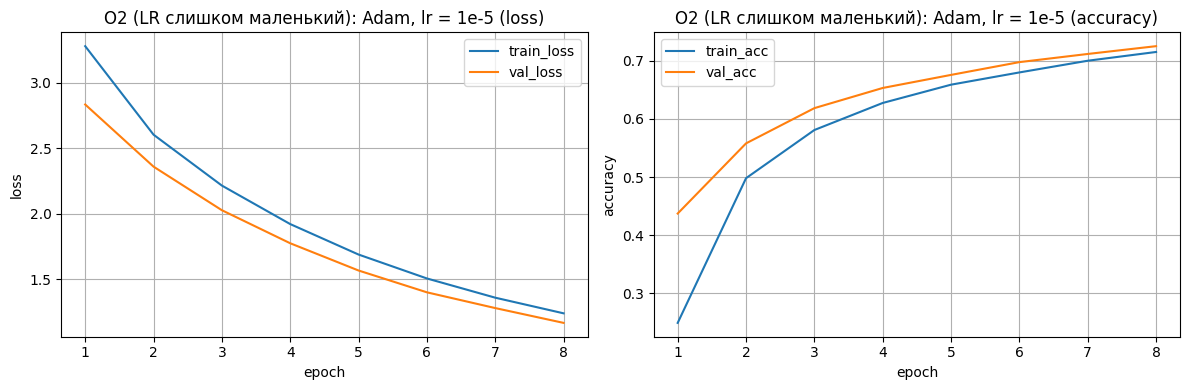

O2 test: loss=1.1743, acc=0.7231


In [ ]:
# O2 
set_seed(42)
o2_model = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=best_hidden_dims,
    dropout_p=best_dropout_p,
    use_batchnorm=best_use_batchnorm
).to(device)

optimizer_o2 = optim.Adam(o2_model.parameters(), lr=1e-5)  
print("O2 (LR слишком маленький): Adam, lr = 1e-5")
history_o2 = fit(
    o2_model, train_loader, val_loader,
    optimizer_o2, criterion, device,
    epochs=8, 
    early_stopping=None,
    verbose=True
)

plot_and_save_history(history_o2, title="O2 (LR слишком маленький): Adam, lr = 1e-5", save_path="./artifacts/figures/history_o2.png")

test_loss, test_acc = evaluate(o2_model, test_loader, criterion, device)
print(f"O2 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

O3 (SGD+momentum + weight decay): SGD с momentum=0.9 и weight_decay=1e-4
epoch 01/15 | train loss=0.9263, acc=0.7305 | val loss=0.5813, acc=0.8134
epoch 02/15 | train loss=0.5521, acc=0.8171 | val loss=0.5246, acc=0.8281
epoch 03/15 | train loss=0.4794, acc=0.8370 | val loss=0.4770, acc=0.8432
epoch 04/15 | train loss=0.4358, acc=0.8486 | val loss=0.4768, acc=0.8407
epoch 05/15 | train loss=0.4033, acc=0.8577 | val loss=0.4506, acc=0.8511
epoch 06/15 | train loss=0.3844, acc=0.8630 | val loss=0.4512, acc=0.8480
epoch 07/15 | train loss=0.3652, acc=0.8682 | val loss=0.4520, acc=0.8488
epoch 08/15 | train loss=0.3498, acc=0.8714 | val loss=0.4441, acc=0.8513
epoch 09/15 | train loss=0.3372, acc=0.8771 | val loss=0.4414, acc=0.8498
epoch 10/15 | train loss=0.3243, acc=0.8818 | val loss=0.4438, acc=0.8513
epoch 11/15 | train loss=0.3150, acc=0.8834 | val loss=0.4443, acc=0.8515
epoch 12/15 | train loss=0.3033, acc=0.8857 | val loss=0.4496, acc=0.8519
epoch 13/15 | train loss=0.2968, acc=0.

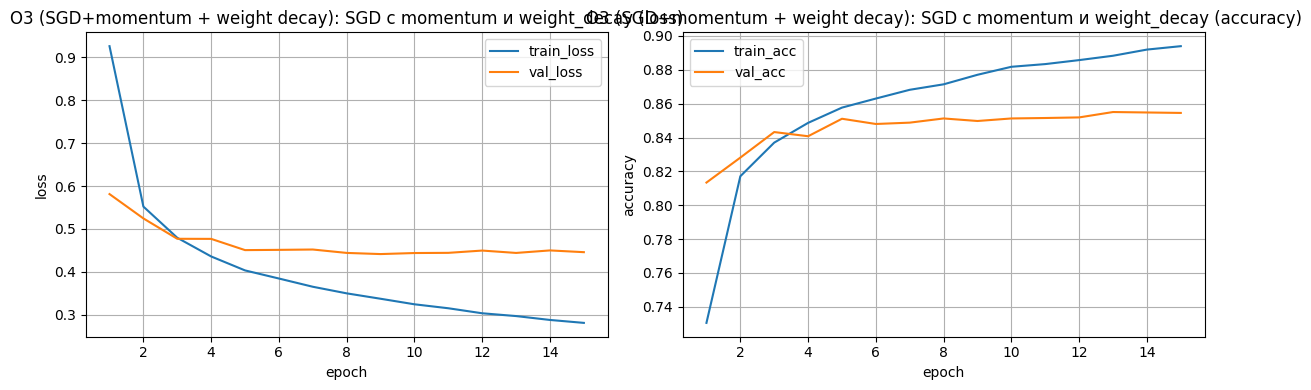

O3 test: loss=0.4732, acc=0.8470


In [ ]:
# O3 
set_seed(42)
o3_model = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=best_hidden_dims,
    dropout_p=best_dropout_p,
    use_batchnorm=best_use_batchnorm
).to(device)

optimizer_o3 = optim.SGD(o3_model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

print("O3 (SGD+momentum + weight decay): SGD с momentum=0.9 и weight_decay=1e-4")
history_o3 = fit(
    o3_model, train_loader, val_loader,
    optimizer_o3, criterion, device,
    epochs=15,  
    early_stopping=None,
    verbose=True
)

plot_and_save_history(history_o3, title="O3 (SGD+momentum + weight decay): SGD с momentum и weight_decay", save_path="./artifacts/figures/history_o3.png")

test_loss, test_acc = evaluate(o3_model, test_loader, criterion, device)
print(f"O3 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## 6. Сохранение результатов

In [ ]:
results_data = [
    {
        "experiment_id": "E1",
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hidden sizes {best_hidden_dims} / activation relu / dropout 0.0 / batchnorm False",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e1["train_loss"]),
        "best_val_accuracy": max(history_e1["val_acc"]),
        "best_val_loss": min(history_e1["val_loss"])
    },
    {
        "experiment_id": "E2",
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hidden sizes {best_hidden_dims} / activation relu / dropout 0.3 / batchnorm False",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e2["train_loss"]),
        "best_val_accuracy": max(history_e2["val_acc"]),
        "best_val_loss": min(history_e2["val_loss"])
    },
    {
        "experiment_id": "E3",
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hidden sizes {best_hidden_dims} / activation relu / dropout 0.0 / batchnorm True",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e3["train_loss"]),
        "best_val_accuracy": max(history_e3["val_acc"]),
        "best_val_loss": min(history_e3["val_loss"])
    },
    {
        "experiment_id": "E4",
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hidden sizes {best_hidden_dims} / activation relu / dropout {best_dropout_p} / batchnorm {best_use_batchnorm}",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e4["train_loss"]),
        "best_val_accuracy": max(history_e4["val_acc"]),
        "best_val_loss": min(history_e4["val_loss"])
    },
    {
        "experiment_id": "O1",
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hidden sizes {best_hidden_dims} / activation relu / dropout {best_dropout_p} / batchnorm {best_use_batchnorm}",
        "optimizer": "Adam",
        "lr": 1e-1,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_o1["train_loss"]),
        "best_val_accuracy": max(history_o1["val_acc"]),
        "best_val_loss": min(history_o1["val_loss"])
    },
    {
        "experiment_id": "O2",
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hidden sizes {best_hidden_dims} / activation relu / dropout {best_dropout_p} / batchnorm {best_use_batchnorm}",
        "optimizer": "Adam",
        "lr": 1e-5,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_o2["train_loss"]),
        "best_val_accuracy": max(history_o2["val_acc"]),
        "best_val_loss": min(history_o2["val_loss"])
    },
    {
        "experiment_id": "O3",
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hidden sizes {best_hidden_dims} / activation relu / dropout {best_dropout_p} / batchnorm {best_use_batchnorm}",
        "optimizer": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs_trained": len(history_o3["train_loss"]),
        "best_val_accuracy": max(history_o3["val_acc"]),
        "best_val_loss": min(history_o3["val_loss"])
    }
]

df_results = pd.DataFrame(results_data)
df_results.to_csv("./artifacts/runs.csv", index=False)
print("Таблица результатов сохранена в artifacts/runs.csv")
print(df_results[["experiment_id", "best_val_accuracy", "best_val_loss"]])

Таблица результатов сохранена в artifacts/runs.csv
  experiment_id  best_val_accuracy  best_val_loss
0            E1           0.839071       0.492597
1            E2           0.824506       0.533261
2            E3           0.856815       0.440779
3            E4           0.856815       0.440779
4            O1           0.799612       0.660155
5            O2           0.725194       1.164572
6            O3           0.855049       0.441405


In [ ]:
torch.save(e4_model.state_dict(), "./artifacts/best_model.pt")
print("Лучшая модель сохранена в artifacts/best_model.pt")

best_config = {
    "model_architecture": {
        "input_dim": input_dim,
        "hidden_dims": best_hidden_dims,
        "num_classes": num_classes,
        "activation": "relu",
        "dropout_p": best_dropout_p,
        "use_batchnorm": best_use_batchnorm
    },
    "training_config": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "criterion": "CrossEntropyLoss",
        "batch_size": BATCH_SIZE,
        "early_stopping": {
            "patience": 4,
            "min_delta": 0.0005
        }
    },
    "dataset": dataset_name,
    "seed": 42,
    "epochs_trained": len(history_e4["train_loss"]),
    "final_val_accuracy": history_e4["val_acc"][-1],
    "final_val_loss": history_e4["val_loss"][-1],
    "best_val_accuracy": max(history_e4["val_acc"]),
    "best_val_loss": min(history_e4["val_loss"])
}

with open("./artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)
print("сохранен в artifacts/best_config.json")

Лучшая модель сохранена в artifacts/best_model.pt
сохранен в artifacts/best_config.json


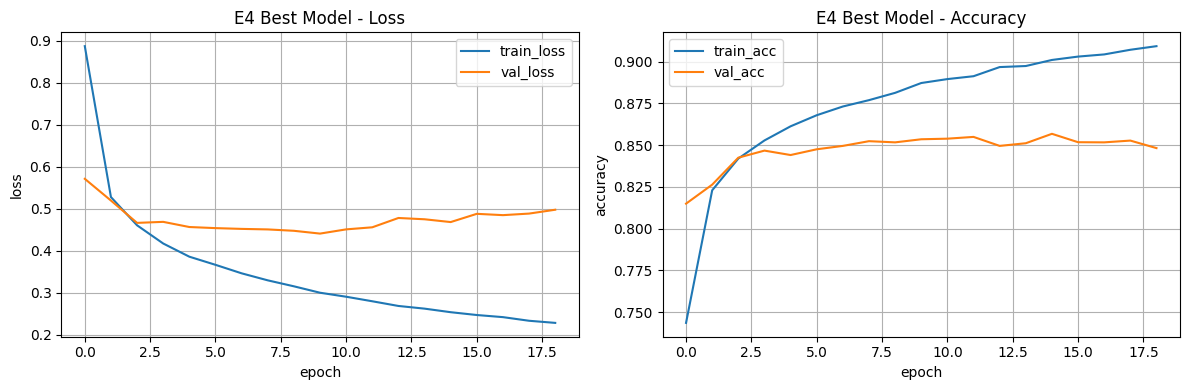

График лучшего прогона сохранен в artifacts/figures/curves_best.png


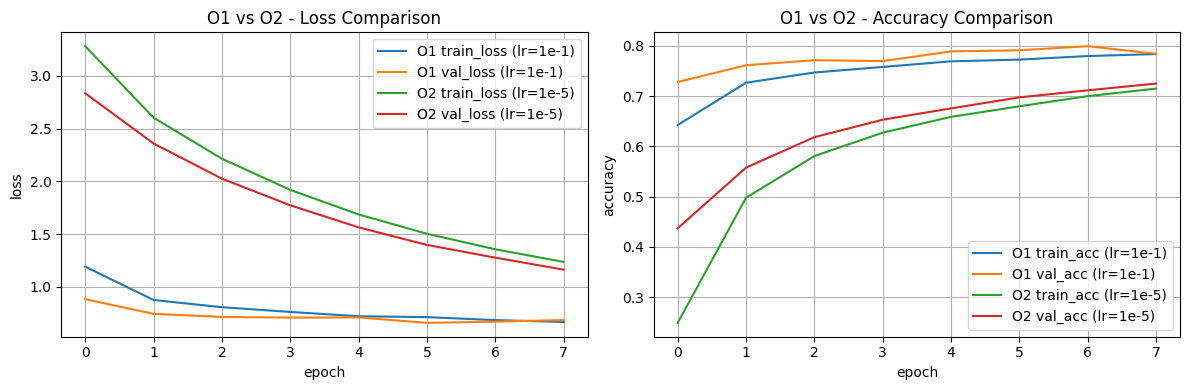

сохранен в artifacts/figures/curves_lr_extremes.png


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_e4["train_loss"], label="train_loss")
plt.plot(history_e4["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("E4 Best Model - Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_e4["train_acc"], label="train_acc")
plt.plot(history_e4["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("E4 Best Model - Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("./artifacts/figures/curves_best.png")
plt.show()
print("График лучшего прогона сохранен в artifacts/figures/curves_best.png")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_o1["train_loss"], label="O1 train_loss (lr=1e-1)")
plt.plot(history_o1["val_loss"], label="O1 val_loss (lr=1e-1)")
plt.plot(history_o2["train_loss"], label="O2 train_loss (lr=1e-5)")
plt.plot(history_o2["val_loss"], label="O2 val_loss (lr=1e-5)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("O1 vs O2 - Loss Comparison")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o1["train_acc"], label="O1 train_acc (lr=1e-1)")
plt.plot(history_o1["val_acc"], label="O1 val_acc (lr=1e-1)")
plt.plot(history_o2["train_acc"], label="O2 train_acc (lr=1e-5)")
plt.plot(history_o2["val_acc"], label="O2 val_acc (lr=1e-5)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("O1 vs O2 - Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("./artifacts/figures/curves_lr_extremes.png")
plt.show()
print("сохранен в artifacts/figures/curves_lr_extremes.png")

In [ ]:
final_test_loss, final_test_acc = evaluate(e4_model, test_loader, criterion, device)
print(f"Финальная оценка лучшей модели (E4) на test: loss={final_test_loss:.4f}, acc={final_test_acc:.4f}")

Финальная оценка лучшей модели (E4) на test: loss=0.4896, acc=0.8534
